# 02 — D2 `rule_composite_riskoff` (Reglas / Umbrales, voto multivariante)

D1 dejó un hueco claro: un detector de VIX-solo infra-detecta las crisis sin pico de miedo (la inflación de 2022). D2 ataca justo eso. Es una regla **compuesta** y causal: agrega 4 señales de estrés ya causales de `features.parquet` en un **score de risk-off** —un voto promedio donde ALTO = estrés— y lo umbraliza con la misma maquinaria de D1 (**histéresis** τ_in/τ_out + **dwell-time** mínimo), pero sobre un VOTO multivariante en vez de un único nivel de VIX. 2 estados: 0=calma, 1=crisis (varias señales risk-off encendidas a la vez).

**Señales y orientación** (signo con que entran al score, ALTO=estrés):
- `VIX_level_z` (+): miedo equity (bloom2009).
- `credit_spread_z` (−): ret(HYG)−ret(IEF); el deterioro de crédito lo vuelve NEGATIVO (Gilchrist-Zakrajšek 2012).
- `yield_slope_z` (−): pendiente 10Y−3M; curva baja/invertida = estrés (Estrella-Mishkin 1998). Signo INVERTIDO.
- `SP500_drawdown` (−): drawdown corriente ∈[−1,0] (kritzman2012).

**Ventana**: crédito (HYG) y curva existen en `features.parquet` desde 2007-07. Con `train_size≈8 años` el primer bloque OOS cae hacia 2015, así que **2008 y 2011 quedan en el train inicial → cobertura NaN out-of-sample** (límite de datos, no del detector; correcto y declarado): D2 solo se evalúa OOS sobre 2020 y 2022.

**Hipótesis CHECKPOINT 2 (D2)**: *captará estrés multivariante equity+crédito+curva en 2008/2011/2020/2022; fallará por calibración de pesos sensible*. La contrastamos al final.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
from src import evaluation as ev
from detectors.rule_composite_riskoff import RuleCompositeRiskoff

feats = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
print('features:', feats.shape, '|', feats.index.min().date(), '->', feats.index.max().date())

features: (4665, 15) | 2007-07-06 -> 2026-06-12


## 1. Señales del voto + retorno del S&P 500 (market_returns)

`X` = las 4 señales causales que componen el score. `market_returns` = **retorno log del S&P 500** (`np.log(raw['SP500']/raw['SP500'].shift(1))`) reindexado a `X`. Lo pasamos SIEMPRE a `walk_forward` y a `evaluate` para que el núcleo re-fije el orden económico de estados (0=calma..n−1=crisis) por su retorno realizado y NO haya warning de fallback: el estado "crisis" se deduce de los datos, no se impone a mano.

In [2]:
SIGNALS = ['VIX_level_z', 'credit_spread_z', 'yield_slope_z', 'SP500_drawdown']
X = feats[SIGNALS].dropna().copy()
X.index = pd.to_datetime(X.index); X = X.sort_index()
market_returns = np.log(raw['SP500'] / raw['SP500'].shift(1)).rename('SP500_ret')
market_returns = market_returns.reindex(X.index)
print('X (desde HYG/curva):', X.shape, '|', X.index.min().date(), '->', X.index.max().date())
print('Orientación estrés (ALTO=risk-off):', RuleCompositeRiskoff().signs)
X.head(3)

X (desde HYG/curva): (4665, 4) | 2007-07-06 -> 2026-06-12
Orientación estrés (ALTO=risk-off): {'VIX_level_z': 1, 'credit_spread_z': -1, 'yield_slope_z': -1, 'SP500_drawdown': -1}


,VIX_level_z,credit_spread_z,yield_slope_z,SP500_drawdown
date,,,,
2007-07-06,-0.649340,1.076833,-1.177578,-0.005678
2007-07-09,-0.580730,-0.205217,-1.203925,-0.004762
2007-07-10,-0.205364,-2.833249,-1.324621,-0.018880


**Dirección de estrés empírica** de cada señal: media por ventana de crisis. Confirma los signos elegidos (VIX alto, credit_spread_z bajo/negativo, yield_slope_z bajo, drawdown negativo = estrés). Pero atención a la grieta que esto ya revela: la curva se **EMPINÓ** en 2008/2011 (la Fed recortando el tipo corto), de modo que es una señal **adelantada**, no contemporánea al estrés —la fuente de la fricción de pesos que anticipa la hipótesis del CP2—.

In [3]:
wins = {**ev.CRISIS_WINDOWS, 'calm_2017': ('2017-01-01','2017-12-31')}
tbl = {w: {c: round(float(feats.loc[a:b, c].mean()), 2) for c in SIGNALS}
       for w, (a, b) in wins.items()}
pd.DataFrame(tbl).T

,VIX_level_z,credit_spread_z,yield_slope_z,SP500_drawdown
GFC_2008,3.92,-0.21,0.82,-0.42
EuroDebt_2011,1.30,-0.09,0.35,-0.22
COVID_2020,3.46,-0.34,-1.22,-0.18
Inflation_2022,0.83,0.03,-0.50,-0.14
calm_2017,-1.08,0.01,-0.48,-0.01


## 2. El detector D2 y su score compuesto causal

`RuleCompositeRiskoff(q_in=0.90, q_out=0.70, min_dwell=5)`: cada señal se orienta (signo·valor, para que ALTO=estrés), se **re-estandariza con μ/σ del train** (causal, y necesario porque el drawdown vive en [−1,0] mientras las demás son z≈unitarias) y se promedia con pesos iguales → **score de risk-off**. τ_in/τ_out = percentiles 90/70 del score en el train. El ajuste sobre todo el histórico es SOLO para inspección; la evaluación honesta es el walk-forward de la sección 3.

In [4]:
det0 = RuleCompositeRiskoff(q_in=0.90, q_out=0.70, min_dwell=5).fit(X)
print(f'τ_in  (q=0.90) = {det0._tau_in:.3f}  (unidades de score)')
print(f'τ_out (q=0.70) = {det0._tau_out:.3f}')
print('pesos:', det0.weights)
print('bibliografía:', det0.bibliography)
# Re-fijar orden económico con market_returns (lo que hace walk_forward por fold).
det0.label_states_economically(X, market_returns=market_returns)
print('canonical order =', det0._canonical_order, '| crisis_state =', det0.crisis_state)
states_is = pd.Series(det0.predict(X), index=X.index)
byst = {int(s): round(float(market_returns[states_is == s].mean()), 5) for s in [0, 1]}
print('retorno medio S&P por estado:', byst, '-> 1=crisis (peor) =', byst[1] < byst[0])
assert det0.crisis_state == 1 and byst[1] < byst[0], 'crisis canónico != voto risk-off'
print('% días crisis in-sample:', round(float((states_is == det0.crisis_state).mean()), 3))

τ_in  (q=0.90) = 0.616  (unidades de score)
τ_out (q=0.70) = 0.140
pesos: {'VIX_level_z': 1.0, 'credit_spread_z': 1.0, 'yield_slope_z': 1.0, 'SP500_drawdown': 1.0}
bibliografía: ['reglas_gilchristzakrajsek2012', 'estrellamishkin1998', 'reglas_bloom2009', 'kritzman2012']
canonical order = [0 1] | crisis_state = 1


retorno medio S&P por estado: {0: 0.00116, 1: -0.00337} -> 1=crisis (peor) = True
% días crisis in-sample: 0.192


## 3. Walk-forward causal (2008/2011 en el train inicial → NaN OOS)

El **walk-forward** reentrena en ventanas crecientes y predice solo el bloque siguiente sin ver el futuro (cada día clasificado es *out-of-sample*), **pasando `market_returns`** para re-fijar el orden de estados por fold. Como `X` arranca en 2007 y `train_size≈8 años`, el panel OOS empieza hacia 2015: **2008 y 2011 NO son evaluables OOS** (caen íntegras en el train inicial) y saldrán como NaN —un límite de datos honesto, no una omisión—. Solo 2020 y 2022 (y la trampa de 2018) son juzgables.

In [5]:
factory = lambda: RuleCompositeRiskoff(q_in=0.90, q_out=0.70, min_dwell=5)
panel = ev.walk_forward(factory, X, market_returns=market_returns,
                        train_size=252*8, step=21, expanding=True)
print('Panel OOS:', panel.shape, '|', panel.index.min().date(), '->', panel.index.max().date())
panel.head(3)

Panel OOS: (2649, 3) | 2015-09-15 -> 2026-06-12


,state,p_crisis,fold
date,,,
2015-09-15,0,0.0,0
2015-09-16,0,0.0,0
2015-09-17,0,0.0,0


## 4. Evaluación estandarizada y fila de métricas (23 columnas)

`ev.evaluate` con `market_returns` produce la misma fila comparable que D1: cobertura por crisis, falsas alarmas (global y en trampas), lead/lag, switching/persistencia y estabilidad de etiquetas. Se vuelca a `results/metrics_02_rule_composite_riskoff.csv` para la síntesis comparativa de FASE 4.

In [6]:
res = ev.evaluate(det0, panel, market_returns=market_returns, X_full=X)
row = ev.results_table([res])
out_csv = RESULTS / 'metrics_02_rule_composite_riskoff.csv'
row.to_csv(out_csv, index=False)
print('ventana_eval:', res.extra['ventana_eval'])
print('retorno medio S&P por estado:', {k: round(v,5) for k,v in res.extra['mean_return_by_state'].items()})
print('columnas:', row.shape[1], '| guardado:', out_csv.name)
row.T

ventana_eval: 2015-09-15→2026-06-12 (n=2649)
retorno medio S&P por estado: {0: 0.00117, 1: -0.00222}
columnas: 32 | guardado: metrics_02_rule_composite_riskoff.csv


,0
detector,rule_composite_riskoff
n_states,2
ventana_eval,2015-09-15→2026-06-12 (n=2649)
oos_start,2015-09-15
oos_end,2026-06-12
n_oos,2649
false_alarm_rate,0.724508
switching_rate,0.038505
mean_regime_duration,25.718447
label_stability,0.999622


## 5. Visualización — S&P 500 coloreado por régimen (OOS)

Lectura visual: S&P 500 (log) con los días OOS clasificados como **crisis** sombreados; bandas de crisis conocidas (rojo) y trampas 2013/2018 (naranja). La zona pre-2015 es el train inicial y aparece sin etiqueta OOS —de ahí los NaN de 2008/2011—.

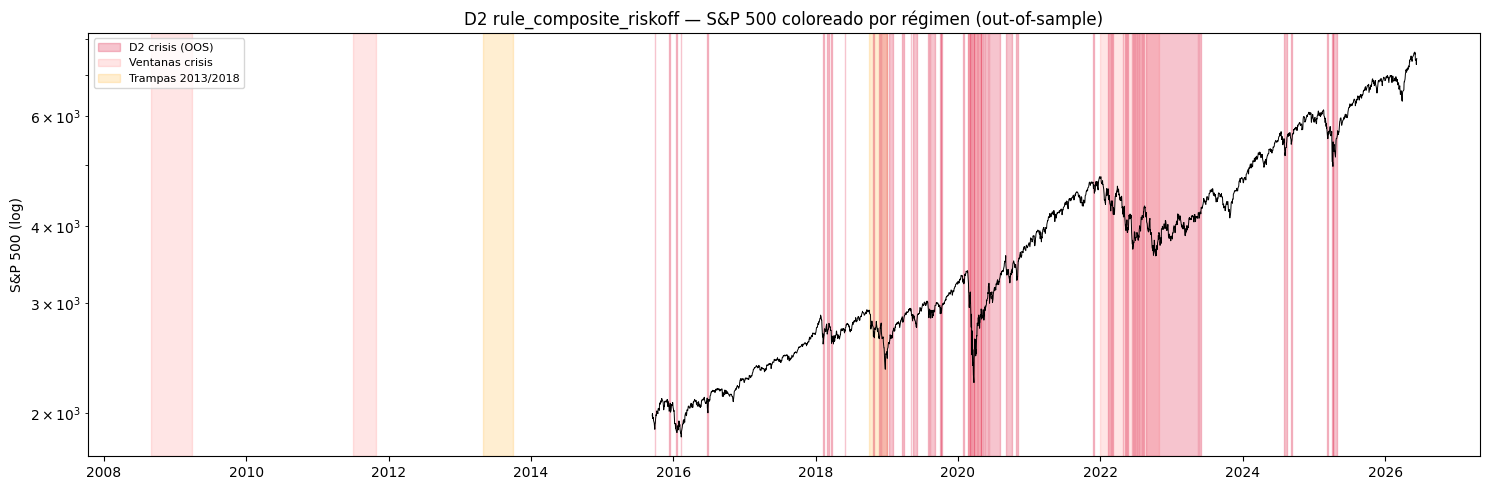

In [7]:
spx = raw['SP500'].reindex(panel.index)
is_crisis = (panel['state'] == det0.crisis_state)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(spx.index, spx, color='black', lw=0.7, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
ymin, ymax = ax.get_ylim()
ax.fill_between(panel.index, ymin, ymax, where=is_crisis.values, color='crimson',
                alpha=0.25, step='mid', zorder=1)
ax.set_ylim(ymin, ymax)
for a, b in ev.CRISIS_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.10, zorder=0)
for a, b in ev.FALSE_POSITIVE_WINDOWS.values():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.18, zorder=0)
handles = [Patch(color='crimson', alpha=0.25, label='D2 crisis (OOS)'),
           Patch(color='red', alpha=0.10, label='Ventanas crisis'),
           Patch(color='orange', alpha=0.18, label='Trampas 2013/2018')]
ax.legend(handles=handles, loc='upper left', fontsize=8)
ax.set_title('D2 rule_composite_riskoff — S&P 500 coloreado por régimen (out-of-sample)')
fig.tight_layout(); fig.savefig(RESULTS / 'd2_regime_sp500.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Score compuesto vs umbral + contribución de cada señal + timeline

El panel que justifica el voto. Arriba: score de risk-off OOS contra τ_in/τ_out (histéresis). En medio: la z orientada de cada señal (ALTO=estrés), para leer QUÉ aporta cada componente en cada episodio —y ver, por ejemplo, si la curva resta cuando debería sumar—. Abajo: timeline de régimen (banda roja = crisis).

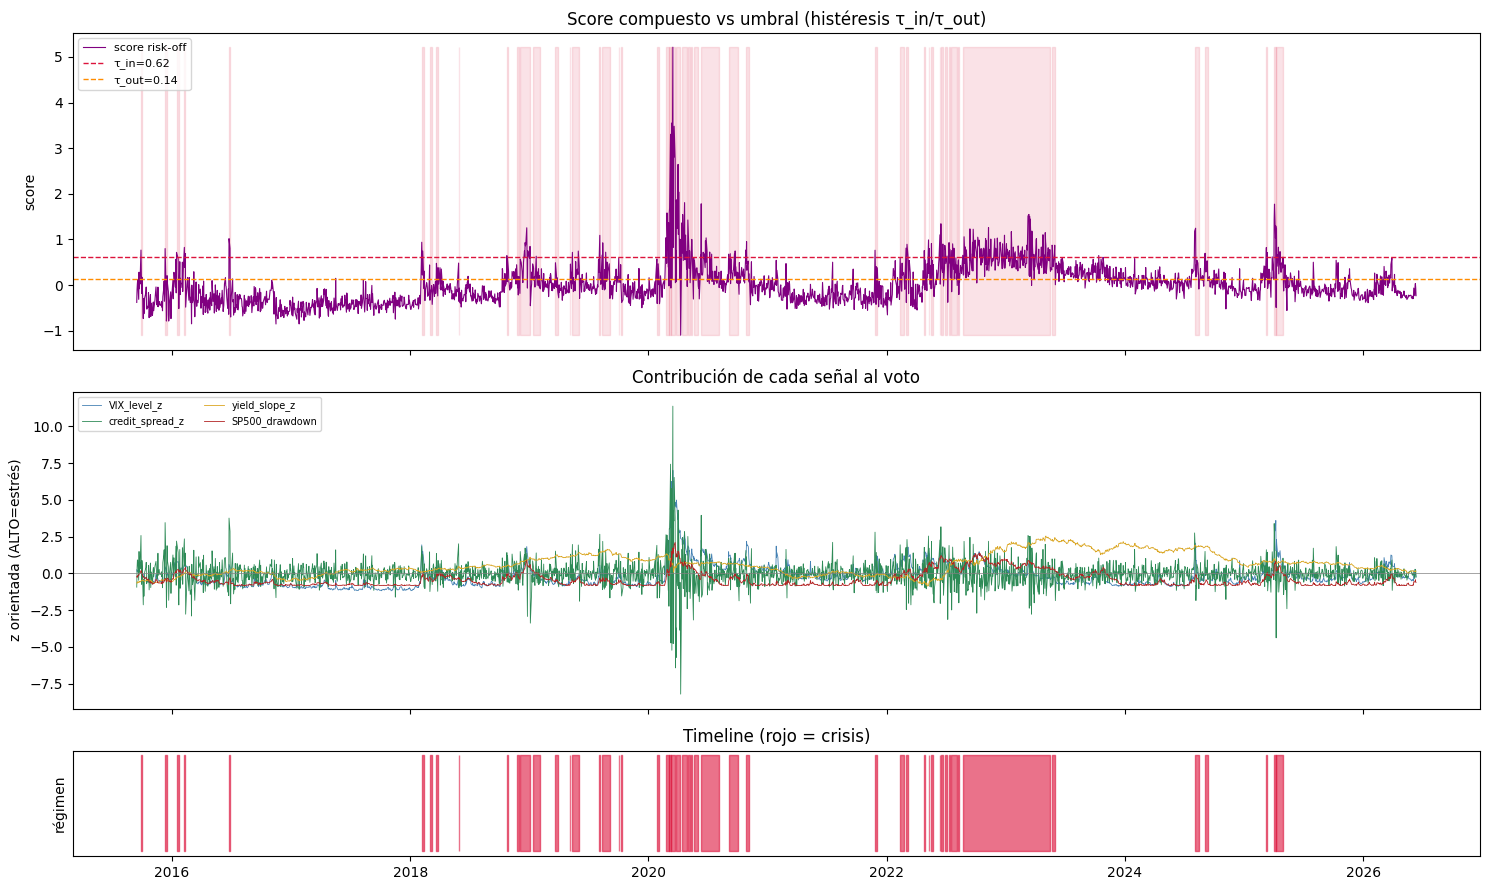

In [8]:
score = pd.Series(det0.composite_score(X), index=X.index).reindex(panel.index)
# z orientadas por señal (con μ/σ del fit de inspección)
ori = det0._oriented(X.reindex(panel.index))
zsig = {f: (ori[f] - det0._mu[f]) / (det0._sigma[f] if det0._sigma[f] > 0 else 1.0)
        for f in det0.features}
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 9), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 3, 1]})
ax1.plot(score.index, score, color='purple', lw=0.8, label='score risk-off')
ax1.axhline(det0._tau_in, color='crimson', ls='--', lw=1, label=f'τ_in={det0._tau_in:.2f}')
ax1.axhline(det0._tau_out, color='darkorange', ls='--', lw=1, label=f'τ_out={det0._tau_out:.2f}')
ax1.fill_between(panel.index, score.min(), score.max(), where=is_crisis.values,
                 color='crimson', alpha=0.12, step='mid')
ax1.set_ylabel('score'); ax1.legend(loc='upper left', fontsize=8)
ax1.set_title('Score compuesto vs umbral (histéresis τ_in/τ_out)')
for f, c in zip(det0.features, ['steelblue','seagreen','goldenrod','firebrick']):
    ax2.plot(panel.index, zsig[f], lw=0.6, color=c, label=f)
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_ylabel('z orientada (ALTO=estrés)'); ax2.legend(loc='upper left', fontsize=7, ncol=2)
ax2.set_title('Contribución de cada señal al voto')
ax3.fill_between(panel.index, 0, 1, where=is_crisis.values, color='crimson', alpha=0.6, step='mid')
ax3.set_yticks([]); ax3.set_ylabel('régimen'); ax3.set_title('Timeline (rojo = crisis)')
fig.tight_layout(); fig.savefig(RESULTS / 'd2_score_timeline.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Verificación explícita contra crisis y trampas

Prueba episodio por episodio. Cobertura (% días crisis) en cada ventana conocida y activación en cada trampa. 2008/2011 salen NaN (en el train inicial). Para 2020/2022: alto=bueno (sensibilidad). Para las trampas 2013/2018: bajo=bueno (especificidad).

In [9]:
states_oos = panel['state']
cov = ev.crisis_coverage(states_oos, det0.crisis_state)
fa  = ev.false_alarm_in_windows(states_oos, det0.crisis_state)
print('=== COBERTURA EN CRISIS (alto = bueno; NaN = en train inicial) ===')
for k, v in cov.items():
    tag = 'sin OOS (train)' if v != v else ('OK' if v >= 0.5 else 'BAJA')
    print(f'  {k:16s}: ' + ('  NaN' if v != v else f'{v:6.2%}') + f'  [{tag}]')
print('\n=== ACTIVACIÓN EN TRAMPAS (bajo = bueno) ===')
for k, v in fa.items():
    print(f'  {k:16s}: ' + ('  NaN (train)' if v != v else f'{v:6.2%}'))
print(f'\nfalse_alarm_rate global: {res.false_alarm_rate:.2%}')
print(f'switching_rate: {res.switching_rate:.4f}  |  duración media régimen: {res.mean_regime_duration:.1f} días')
print(f'label_stability: {res.label_stability:.3f}')

=== COBERTURA EN CRISIS (alto = bueno; NaN = en train inicial) ===
  GFC_2008        :   NaN  [sin OOS (train)]
  EuroDebt_2011   :   NaN  [sin OOS (train)]
  COVID_2020      : 84.00%  [OK]
  Inflation_2022  : 53.85%  [OK]

=== ACTIVACIÓN EN TRAMPAS (bajo = bueno) ===
  TaperTantrum_2013:   NaN (train)
  Selloff_Q4_2018 : 42.37%

false_alarm_rate global: 72.45%
switching_rate: 0.0385  |  duración media régimen: 25.7 días
label_stability: 1.000


## 8. Comparación con D1 (VIX-solo) y veredicto sobre la hipótesis del CP2

La celda siguiente carga la fila de D1 y compara cobertura, falsas alarmas y persistencia. La pregunta clave: ¿el voto compuesto capta estrés multivariante (crédito + drawdown + curva) que el VIX solo no ve, sobre todo en el bear market de tipos de 2022?

**Veredicto** —cumplido en lo esencial, con matices, sin "demostrar" nada (n≈4 crisis, sin tests de significancia, y 2008/2011 fuera de OOS)—:

- **Sí donde se esperaba**: en 2022 la cobertura sube de **34.9% (D1) a 53.8% (D2)**, +18.9 pp, al sumar crédito y drawdown a la señal de miedo. Es **consistente con** el motivo de existir de D2 frente al baseline univariante. En COVID 2020 queda algo por debajo de D1 (84.0% vs 90.0%).
- **El coste, confirmado**: más falsas alarmas y más parpadeo. En la trampa de Q4 2018 D2 se activa el **42.4%** de los días (vs 6.3% de D1), el `switching_rate` casi se triplica (0.0385 vs 0.0132) y la duración media de régimen cae a **~26 días** (vs ~75 de D1). Combinar 4 señales con pesos iguales mete más ruido; la histéresis lo contiene pero no lo elimina al nivel de D1.
- **Calibración de pesos sensible: confirmada**. La curva (`yield_slope_z`) es adelantada y RESTA score justo en 2008/2011 (cuando se empinó), pero suma en 2020/2022: el voto con pesos iguales es por tanto sensible a qué señal domina cada episodio. **2008/2011 no son juzgables OOS** por la ventana de HYG, así que esa parte de la hipótesis queda **sin verificar por datos, no refutada**.

**Mejor-para-qué**: D2 NO domina a D1. Gana en estrés multivariante lento (2022), pierde en especificidad (2018), persistencia y switching. Son **complementarios**: D1 = miedo limpio y persistente; D2 = sensibilidad a crédito/drawdown a costa de ruido. La síntesis de FASE 4 los trata como señales que se combinan, no como sustitutos. Discusión completa en `docs/memory/detectors/02_rule_composite_riskoff.md`.

In [10]:
d1_csv = RESULTS / 'metrics_01_rule_vix_threshold.csv'
cmp_cols = ['detector','ventana_eval','cov_COVID_2020','cov_Inflation_2022',
            'fa_Selloff_Q4_2018','false_alarm_rate','switching_rate','mean_regime_duration']
rows = [row]
if d1_csv.exists():
    rows.insert(0, pd.read_csv(d1_csv))
cmp = pd.concat(rows, ignore_index=True)[cmp_cols]
print('Comparación D1 (VIX-solo) vs D2 (voto compuesto):')
import IPython.display as disp
disp.display(cmp.set_index('detector').T)
d1_infl = float(pd.read_csv(d1_csv)['cov_Inflation_2022'].iloc[0]) if d1_csv.exists() else float('nan')
d2_infl = float(row['cov_Inflation_2022'].iloc[0])
print(f'\nInflation 2022: D1(VIX)={d1_infl:.1%}  ->  D2(compuesto)={d2_infl:.1%}  '
      f'(mejora={d2_infl - d1_infl:+.1%})')
print('Hipótesis CP2: captará estrés multivariante 2008/2011/2020/2022; fallará por\n'
      'calibración de pesos sensible. Discusión completa en\n'
      'docs/memory/detectors/02_rule_composite_riskoff.md')

Comparación D1 (VIX-solo) vs D2 (voto compuesto):


detector,rule_vix_threshold,rule_composite_riskoff
ventana_eval,1998-06-23→2026-06-12 (n=6994),2015-09-15→2026-06-12 (n=2649)
cov_COVID_2020,0.9,0.84
cov_Inflation_2022,0.349282,0.538462
fa_Selloff_Q4_2018,0.063492,0.423729
false_alarm_rate,0.697356,0.724508
switching_rate,0.013154,0.038505
mean_regime_duration,75.204301,25.718447



Inflation 2022: D1(VIX)=34.9%  ->  D2(compuesto)=53.8%  (mejora=+18.9%)
Hipótesis CP2: captará estrés multivariante 2008/2011/2020/2022; fallará por
calibración de pesos sensible. Discusión completa en
docs/memory/detectors/02_rule_composite_riskoff.md
